# Return convergence — training and in-training eval return, per algorithm

Draws **two figures per algorithm** — the training return
`ray/tune/env_runners/episode_return_mean` and the in-training evaluation return
`ray/tune/evaluation/env_runners/episode_return_mean` — each overlaying that algorithm's three
joint battery-**capacity** × PV-**power** GEN training configurations, so the held-out results
[`sps_eval_catplot_cmp.ipynb`](sps_eval_catplot_cmp.ipynb) reports can be read against how far
each run converged and against how far its training return had separated from its eval return.
The three variants differ only in which battery capacities and PV ratings they saw while
training:

| Variant | Training battery capacity × PV rating |
|---|---|
| spec | single mid-grid config `cfg_5`, fixed 15 kWh battery + 10 kW PV |
| N-way gen. | infra schedule cycling the 3 × 3 grid `cfg_1…9` — battery 10 / 15 / 20 kWh × PV 5 / 10 / 15 kW — every 12 episodes |
| gen. distribution | `BatteryLinearWrapper` + `SolarPanelWrapper` sampling 10-20 kWh × 5-15 kW per episode (1-decimal grid), holding out 12 / 16 kWh and 6 / 12 kW |

Battery power is pinned at 10 kW throughout (in the sampler too: `max_power_range_kW: [10, 10]`),
so capacity and PV rating are the only axes that vary. The four held-out eval configs combine
both — `eval_0` 12 kWh / 6 kW, `eval_1` 16 kWh / 12 kW, `eval_2` 12 kWh / 12 kW, `eval_3`
16 kWh / 6 kW — interpolation points inside both training ranges.

> **What the eval curve measures.** The in-training eval runs 10 episodes every 10 training
> iterations (`training_params.common.evaluation`: `interval` / `duration`) on the eval data
> schedule, but on the **training-side infra config**: the eval env is built from
> `infra_schedule.configs.train[0]` like the training envs, and the infra-schedule callback
> pushes every N-way swap to the eval env runners as well. For `gen. distribution` that first
> train config is the sampler itself, so its eval episodes draw fresh sizes from the training
> distribution. None of the three ever sees the held-out `eval_0…3` configs the catplot notebook
> evaluates. Between two eval rounds the result carries the last round's value forward, so from
> iteration 10 on every iteration has an eval point but only every 10th is new — the raw eval
> line is a staircase.

For every snapshot the main RLlib TBX event file written by `tuner.fit()` under
`runs/train_*/models/**/events.out.tfevents.*` is parsed (the `ep_metrics/eval_trajectories/`
sub-runs live outside `models/` and are not matched by that glob) and three scalars are
extracted in a single pass: the two return curves above and the lifetime env-step counter
`ray/tune/env_runners/num_env_steps_sampled_lifetime`.

> **x-axis.** These snapshots were taken on top of commit `383a3e7` "Use env steps as
> TensorBoard STEP axis" (2026-07-15), so their TBX step already *is* the env-step counter
> (identical on every logged row). The counter is nevertheless read explicitly and used as the
> x-axis — as in the battery-capacity notebook, whose older logs are indexed by training
> iteration — so the plot does not depend on which step axis a log was written with. One
> iteration is a different amount of experience per algorithm: a PPO iteration advances the
> counter by 3456 (12 × 288; the first by 6912) over 583 iterations — the YAML's
> `ppo.episodes_per_iteration: 10`, raised to 12, the next multiple of the 4 env runners, as
> every PPO training log warns — a SAC one by 576 (4 env runners × the 144-step
> `sac.rollout_length` fragment; twice that on 12 iterations) over 3488, and a DreamerV3 one by
> 288 — a single episode — over 7000. All three nevertheless cover essentially the same
> experience: PPO 2 018 304 steps / 7008 episodes, SAC and DreamerV3 2 016 000 / 7000. With
> `X_AXIS = "episodes"` the counter is shown as `env_steps / EPISODE_LENGTH` with a major tick
> every `X_TICK_EPISODES` (1000) episodes; `X_AXIS = "env_steps"` relabels the same data in
> millions of env steps, ticked every `X_TICK_ENV_STEPS` (250 000).

Parsing an event file is slow (the DreamerV3 logs are ~110 MB), so the extracted curves are
cached as small CSVs under `.tb_return_cache/` next to this notebook; delete that folder to
force a re-parse.

**Main input:** set `SOURCES` in the next cell.

In [1]:
# --- Main input ---------------------------------------------------------------------
# The snapshots whose return curves are plotted. Entries are grouped by "algo": every
# distinct algo gets its own pair of figures (training return, then in-training eval
# return), overlaying that algo's variants. Keys per entry:
#   path     snapshot dir (absolute, or relative to the repo root)
#   algo     algorithm class — one figure pair per distinct value, in first-seen order
#   variant  training configuration; shown in the legend, coloured via VARIANT_COLORS
#
# The DreamerV3 snapshots are clones of the PPO ones — their manifest.json and snapshot.zip
# still name the PPO trial. The trial YAML in their code/ (and the run's own copy) switches to
# algorithm: dreamerv3 (training_ratio 5, horizon_H 30); they were trained on 2026-08-15.

SOURCES = [
    # --- PPO -------------------------------------------------------------------------
    {"path": "snapshots/20260719_171656_gen_lin_bat_pv_spec_ppo", "algo": "PPO", "variant": "spec"},
    {"path": "snapshots/20260719_171650_gen_lin_bat_pv_all_ppo", "algo": "PPO", "variant": "N-way gen."},
    {"path": "snapshots/20260719_171702_gen_lin_bat_pv_sampled_ppo", "algo": "PPO", "variant": "gen. distribution"},
    # --- SAC -------------------------------------------------------------------------
    {"path": "snapshots/20260719_171327_gen_lin_bat_pv_spec_sac", "algo": "SAC", "variant": "spec"},
    {"path": "snapshots/20260719_171314_gen_lin_bat_pv_all_sac", "algo": "SAC", "variant": "N-way gen."},
    {"path": "snapshots/20260719_171333_gen_lin_bat_pv_sampled_sac", "algo": "SAC", "variant": "gen. distribution"},
    # --- DreamerV3 -------------------------------------------------------------------
    {"path": "snapshots/20260720_171656_gen_lin_bat_pv_spec_dreamer", "algo": "DreamerV3", "variant": "spec"},
    {"path": "snapshots/20260720_171650_gen_lin_bat_pv_all_dreamer", "algo": "DreamerV3", "variant": "N-way gen."},
    {"path": "snapshots/20260720_171702_gen_lin_bat_pv_sampled_dreamer", "algo": "DreamerV3", "variant": "gen. distribution"},
]

# Line colour per variant, shared across algorithms so all figures read the same way — the
# same hues the battery-capacity convergence figures (3_gen_bat_cap_v1) give these schemes.
# Legend labels follow the catplot / stats-table notebooks ("N-way gen." for the 3 x 3 grid).
VARIANT_COLORS = {
    "spec": "#0d54c4",                # strong blue
    "N-way gen.": "#e2660a",          # strong orange
    "gen. distribution": "#0a8f52",   # strong green
}

# The two RLlib return scalars, plus the lifetime env-step counter that supplies the
# x-axis. All three are pulled from the same event file in one pass.
TRAIN_METRIC = "ray/tune/env_runners/episode_return_mean"
EVAL_METRIC = "ray/tune/evaluation/env_runners/episode_return_mean"
ENV_STEPS_TAG = "ray/tune/env_runners/num_env_steps_sampled_lifetime"

# The figures drawn per algorithm: (curve column, y-axis label, filename tag).
FIGURE_KINDS = (
    ("train_return", "Mean training return", "train"),
    ("eval_return", "Mean evaluation return", "eval"),
)

# TensorBoard-style EWMA weight in [0, 1): 0 = raw, higher = smoother. The raw curve is drawn
# faint behind the smoothed one when SHOW_RAW is True.
SMOOTHING = 0.99
SHOW_RAW = True

# x-axis unit: "env_steps" plots millions of environment steps, "episodes" plots
# env_steps / EPISODE_LENGTH. Major ticks land every X_TICK_ENV_STEPS / X_TICK_EPISODES.
X_AXIS = "episodes"
X_TICK_ENV_STEPS = 250_000
X_TICK_EPISODES = 1_000
EPISODE_LENGTH = 288

# Upper x-limit (in env steps) shared by every figure so the pairs line up; None takes the
# largest final env-step count across all loaded sources.
X_MAX_ENV_STEPS: float | None = None

# Return-axis major tick spacing, in return units.
Y_TICK_UNITS = 5.0

# Figure size (width, height) in inches for every figure; None keeps the default (9.0, 5.5).
FIGSIZE: tuple[float, float] | None = (8.0, 4.5)

# Grid density: how many sub-intervals each major tick interval is split into by minor
# gridlines (1 = major gridlines only). Minor lines are drawn thinner and fainter.
X_MINOR_DIVISIONS = 2
Y_MINOR_DIVISIONS = 2

In [2]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from tensorboard.backend.event_processing.event_file_loader import EventFileLoader
from tensorboard.util import tensor_util

# Bumped whenever the cached CSV's columns change, so a stale cache is re-parsed rather than read.
CACHE_SCHEMA = "v2-tbstep-envsteps-train-eval"


# Walk upwards from the cwd until the directory containing snapshots/ is found, so the
# notebook runs both from thesis_eval/ and from the repo root.
def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "snapshots").is_dir():
            return candidate
    raise FileNotFoundError("No 'snapshots/' directory found upwards of the cwd — run inside the repo.")


REPO_ROOT = _find_repo_root()

# VS Code exposes the notebook path; a plain Jupyter kernel starts in the notebook's directory.
NB_DIR = Path(globals()["__vsc_ipynb_file__"]).parent if "__vsc_ipynb_file__" in globals() else Path.cwd()
CACHE_DIR = NB_DIR / ".tb_return_cache"


# The main RLlib TBX log under models/ (largest event file wins; the per-episode
# eval_trajectories/ sub-runs live elsewhere and are not matched by this glob).
def _training_event_file(snapshot_dir: Path) -> Path:
    candidates = sorted(
        snapshot_dir.glob("runs/train_*/models/**/events.out.tfevents.*"),
        key=lambda path: path.stat().st_size, reverse=True,
    )
    if not candidates:
        raise FileNotFoundError(f"No training TBX event file under {snapshot_dir / 'runs/train_*/models'}")
    return candidates[0]


# Pulls both return curves and the lifetime env-step counter out of an event file in ONE
# pass (walking the file is the slow part), indexed by the TBX step — the env-step counter
# itself for these snapshots, the training iteration for logs written before 2026-07-15; the
# plots only ever use the explicit env_steps column. Tags that log on different steps (eval
# starts at evaluation_interval) simply leave NaNs in their column.
# Cached as a small CSV keyed by the event file's path + size + mtime, so an updated log
# re-parses. The path is resolved first: this tree is reachable both as /home/... and as
# /hkfs/home/..., and an unresolved key would miss the cache when the kernel reports the
# other form (VS Code's __vsc_ipynb_file__ and the cwd disagree here).
def _extract_curves(event_file: Path) -> pd.DataFrame:
    stat = event_file.stat()
    cache_key = hashlib.md5(f"{event_file.resolve()}|{stat.st_size}|{int(stat.st_mtime)}|{CACHE_SCHEMA}".encode()).hexdigest()
    cache_path = CACHE_DIR / f"{cache_key}.csv"
    if cache_path.exists():
        return pd.read_csv(cache_path)

    wanted = {ENV_STEPS_TAG: "env_steps", TRAIN_METRIC: "train_return", EVAL_METRIC: "eval_return"}
    columns: dict[str, dict[int, float]] = {name: {} for name in wanted.values()}
    for event in EventFileLoader(str(event_file)).Load():
        for value in event.summary.value:
            column = wanted.get(value.tag)
            if column is None:
                continue
            # RLlib writes scalars in the tensor field; legacy simple_value is the fallback.
            scalar = float(tensor_util.make_ndarray(value.tensor)) if value.HasField("tensor") else value.simple_value
            columns[column][event.step] = scalar

    if not columns["env_steps"]:
        raise ValueError(f"Tag {ENV_STEPS_TAG!r} not found in {event_file} — no x-axis available")
    curve = pd.DataFrame(columns).rename_axis("tb_step").sort_index().reset_index()
    CACHE_DIR.mkdir(exist_ok=True)
    curve.to_csv(cache_path, index=False)
    return curve


# TensorBoard's debiased exponential moving average (the "smoothing" slider).
def _tb_smooth(values, weight: float):
    if weight <= 0.0:
        return list(values)
    smoothed, last, debias_weight = [], 0.0, 0.0
    for value in values:
        last = last * weight + (1.0 - weight) * float(value)
        debias_weight = debias_weight * weight + (1.0 - weight)
        smoothed.append(last / debias_weight)
    return smoothed


ALGO_ORDER = list(dict.fromkeys(source["algo"] for source in SOURCES))
source_keys = [(source["algo"], source["variant"]) for source in SOURCES]
if len(source_keys) != len(set(source_keys)):
    raise ValueError(f"Every (algo, variant) pair must be unique; got {source_keys}")
uncoloured = sorted({source["variant"] for source in SOURCES} - VARIANT_COLORS.keys())
if uncoloured:
    raise KeyError(f"VARIANT_COLORS has no entry for {uncoloured}")
print(f"Repo root: {REPO_ROOT}\nCache dir: {CACHE_DIR}\nAlgorithms: {', '.join(ALGO_ORDER)}")

Repo root: /hkfs/home/haicore/iai/dj0397/AdvBuildingGym
Cache dir: /hkfs/home/haicore/iai/dj0397/AdvBuildingGym/thesis_eval/6_gen_bat_cap_pv_power/.tb_return_cache
Algorithms: PPO, SAC, DreamerV3


## Output naming

Everything saved here lands next to the notebook as
`<algo>_<kind>_return_<date>_<time>_out_<i>.<file format>` — e.g. `ppo_train_return_…` and
`ppo_eval_return_…` for the PPO pair: one timestamp per notebook run, `out_index` counting up
per saved artefact, so no run overwrites an earlier one.

In [3]:
from datetime import datetime

OUT_DIR = NB_DIR
OUT_RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
out_index = 0  # incremented once per saved artefact; reset by re-running this cell


def next_out_path(prefix: str, file_format: str) -> Path:
    """Next '<prefix>_<date>_<time>_out_<i>.<file_format>' path in this notebook's directory."""
    global out_index
    out_index += 1
    return OUT_DIR / f"{prefix}_{OUT_RUN_STAMP}_out_{out_index}.{file_format}"

## Load the return curves

Each snapshot's main training event file is located and its three scalars extracted (cached
after the first parse). The table lists, per (algo, variant): how many iterations the run
logged, how much experience that actually was in env steps and episodes, and for each of the
two return curves the number of logged points, the smoothed final value (what the end of the
plotted line shows) and the best raw value.

In [4]:
curves: dict[tuple[str, str], pd.DataFrame] = {}
summary_rows = []
for source in SOURCES:
    snapshot_dir = Path(source["path"])
    snapshot_dir = snapshot_dir if snapshot_dir.is_absolute() else REPO_ROOT / snapshot_dir
    if not snapshot_dir.is_dir():
        raise FileNotFoundError(f"Snapshot directory not found: {snapshot_dir}")
    event_file = _training_event_file(snapshot_dir)
    curve = _extract_curves(event_file)
    curves[(source["algo"], source["variant"])] = curve

    env_steps = curve["env_steps"].dropna()
    final_env_step = int(env_steps.iloc[-1])
    row = {
        "algo": source["algo"],
        "variant": source["variant"],
        # One counter point per Tune result, i.e. per training iteration. The TBX step is the
        # env step for these snapshots, so its maximum is not the iteration count.
        "iterations": len(env_steps),
        "env_steps": final_env_step,
        "episodes": final_env_step // EPISODE_LENGTH,
    }
    for column, _, kind in FIGURE_KINDS:
        series = curve[column].dropna()
        if series.empty:
            raise ValueError(f"No {column!r} points in {event_file}")
        row[f"{kind}_points"] = len(series)
        row[f"{kind}_final_smoothed"] = round(float(_tb_smooth(series.to_numpy(), SMOOTHING)[-1]), 3)
        row[f"{kind}_max_raw"] = round(float(series.max()), 3)
    summary_rows.append(row)
    print(f"{source['algo']:>10} / {source['variant']:<18}: {row['iterations']:>5} iters, {final_env_step:>9,} env steps"
          f"  ->  {event_file.relative_to(REPO_ROOT)}")

summary = pd.DataFrame(summary_rows).set_index(["algo", "variant"])

# Shared upper x-limit (env steps) so every figure spans the same range.
X_MAX = float(X_MAX_ENV_STEPS) if X_MAX_ENV_STEPS is not None else float(summary["env_steps"].max())
print(f"\nShared x-limit: {X_MAX:,.0f} env steps  ({X_MAX / EPISODE_LENGTH:,.0f} episodes)")
summary

       PPO / spec              :   583 iters, 2,018,304 env steps  ->  snapshots/20260719_171656_gen_lin_bat_pv_spec_ppo/runs/train_20260719_171657/models/gen_lin_bat_pv_spec_ppo/ray/ppo/ppo_seed42_20260719_214724/aa0ef_gen_lin_bat_pv_spec_ppo/events.out.tfevents.1784490468.haicn1701.localdomain


       PPO / N-way gen.        :   583 iters, 2,018,304 env steps  ->  snapshots/20260719_171650_gen_lin_bat_pv_all_ppo/runs/train_20260719_171650/models/gen_lin_bat_pv_all_ppo/ray/ppo/ppo_seed42_20260719_214341/250b9_gen_lin_bat_pv_all_ppo/events.out.tfevents.1784490249.haicn1701.localdomain
       PPO / gen. distribution :   583 iters, 2,018,304 env steps  ->  snapshots/20260719_171702_gen_lin_bat_pv_sampled_ppo/runs/train_20260719_171702/models/gen_lin_bat_pv_sampled_ppo/ray/ppo/ppo_seed42_20260719_215126/3a2bd_gen_lin_bat_pv_sampled_ppo/events.out.tfevents.1784490709.haicn1701.localdomain


       SAC / spec              :  3488 iters, 2,016,000 env steps  ->  snapshots/20260719_171327_gen_lin_bat_pv_spec_sac/runs/train_20260719_171327/models/gen_lin_bat_pv_spec_sac/ray/sac/sac_seed42_20260719_171454/989f8_gen_lin_bat_pv_spec_sac/events.out.tfevents.1784474134.haicn1701.localdomain


       SAC / N-way gen.        :  3488 iters, 2,016,000 env steps  ->  snapshots/20260719_171314_gen_lin_bat_pv_all_sac/runs/train_20260719_171314/models/gen_lin_bat_pv_all_sac/ray/sac/sac_seed42_20260719_171454/988b8_gen_lin_bat_pv_all_sac/events.out.tfevents.1784474134.haicn1701.localdomain
       SAC / gen. distribution :  3488 iters, 2,016,000 env steps  ->  snapshots/20260719_171333_gen_lin_bat_pv_sampled_sac/runs/train_20260719_171333/models/gen_lin_bat_pv_sampled_sac/ray/sac/sac_seed42_20260719_171454/989e2_gen_lin_bat_pv_sampled_sac/events.out.tfevents.1784474134.haicn1701.localdomain


 DreamerV3 / spec              :  7000 iters, 2,016,000 env steps  ->  snapshots/20260720_171656_gen_lin_bat_pv_spec_dreamer/runs/train_20260815_133246/models/gen_lin_bat_pv_spec_dreamer/ray/dreamerv3/dreamerv3_seed42_20260815_133349/2f6fc_gen_lin_bat_pv_spec_dreamer/events.out.tfevents.1786793660.haicn1701.localdomain


 DreamerV3 / N-way gen.        :  7000 iters, 2,016,000 env steps  ->  snapshots/20260720_171650_gen_lin_bat_pv_all_dreamer/runs/train_20260815_133231/models/gen_lin_bat_pv_all_dreamer/ray/dreamerv3/dreamerv3_seed42_20260815_133349/2f71f_gen_lin_bat_pv_all_dreamer/events.out.tfevents.1786793660.haicn1701.localdomain
 DreamerV3 / gen. distribution :  7000 iters, 2,016,000 env steps  ->  snapshots/20260720_171702_gen_lin_bat_pv_sampled_dreamer/runs/train_20260815_133303/models/gen_lin_bat_pv_sampled_dreamer/ray/dreamerv3/dreamerv3_seed42_20260815_133349/2f6ff_gen_lin_bat_pv_sampled_dreamer/events.out.tfevents.1786793660.haicn1701.localdomain

Shared x-limit: 2,018,304 env steps  (7,008 episodes)


iterations  env_steps  episodes  train_points  \
algo      variant                                                            
PPO       spec                      583    2018304      7008           583   
          N-way gen.                583    2018304      7008           583   
          gen. distribution         583    2018304      7008           583   
SAC       spec                     3488    2016000      7000          3487   
          N-way gen.               3488    2016000      7000          3487   
          gen. distribution        3488    2016000      7000          3487   
DreamerV3 spec                     7000    2016000      7000          7000   
          N-way gen.               7000    2016000      7000          7000   
          gen. distribution        7000    2016000      7000          7000   

                             train_final_smoothed  train_max_raw  eval_points  \
algo      variant                                                               
PPO       spec                             15.440         21.253          574   
          N-way gen.                       14.464         28.824          574   
          gen. distribution                15.368         21.353          574   
SAC       spec                             17.085         24.222         3479   
          N-way gen.                       14.884         29.897         3479   
          gen. distribution                16.167         25.618         3479   
DreamerV3 spec                             10.472         14.869         6991   
          N-way gen.                        8.650         16.343         6991   
          gen. distribution                10.749         14.228         6991   

                             eval_final_smoothed  eval_max_raw  
algo      variant                                               
PPO       spec                            17.286        19.906  
          N-way gen.                      16.630        20.428  
          gen. distribution               17.471        19.171  
SAC       spec                            17.728        21.290  
          N-way gen.                      17.128        25.481  
          gen. distribution               17.912        21.079  
DreamerV3 spec                            12.486        17.333  
          N-way gen.                      11.261        18.711  
          gen. distribution               12.603        15.986

## Convergence plots

Two figures per algorithm — training return, then in-training evaluation return — each
overlaying that algorithm's three variants in their `VARIANT_COLORS`, smoothed with
TensorBoard's debiased EWMA (`SMOOTHING = 0.99`); the raw curve is drawn faint behind each
smoothed line while `SHOW_RAW` is set. The EWMA weight applies per logged point, i.e. per
iteration, so its effective span in episodes differs by algorithm (a PPO point is 12 episodes of
experience, a SAC point 2, a DreamerV3 point 1) — compare the algorithms' figures by level and
trend, not by the smoothness of their lines.

Both axes are on fixed, readable scales: every figure shares the same x-limit with a major
tick every `X_TICK_EPISODES` = 1000 episodes (every `X_TICK_ENV_STEPS` = 250 000 env steps when
`X_AXIS = "env_steps"`), and the return axis carries a major tick every `Y_TICK_UNITS` = 5
return units. `X_MINOR_DIVISIONS` / `Y_MINOR_DIVISIONS` add a minor gridline halfway between
each pair of major ticks — a thinner, fainter grid at 500 episodes and 2.5 return units — so a
variant's training and eval curves, and the same variant across algorithms, can be read off
against each other. The figures carry **no title** (thesis-ready) and are saved as
`<algo>_<kind>_return_<date>_<time>_out_<i>.pdf` next to this notebook.

PPO — train: saved ppo_train_return_20260923_211442_out_1.pdf


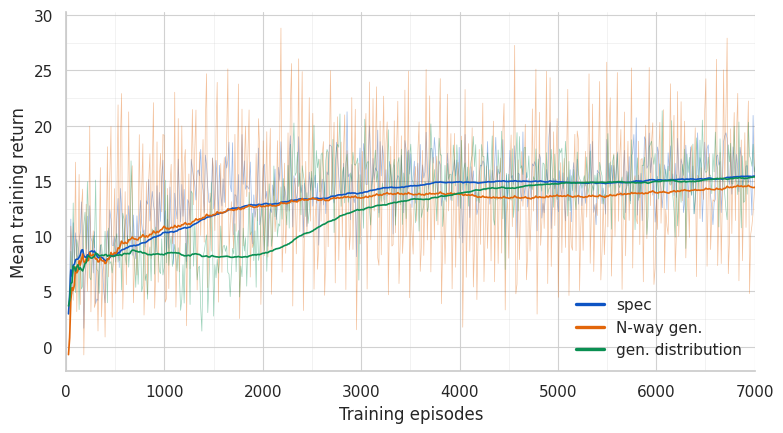

PPO — eval: saved ppo_eval_return_20260923_211442_out_2.pdf


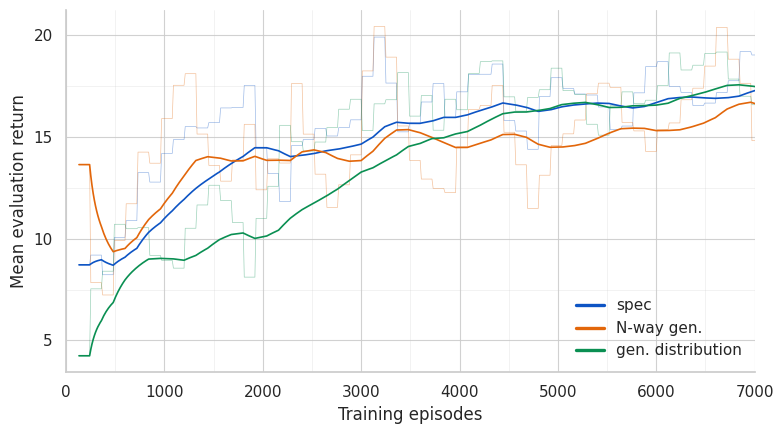

SAC — train: saved sac_train_return_20260923_211442_out_3.pdf


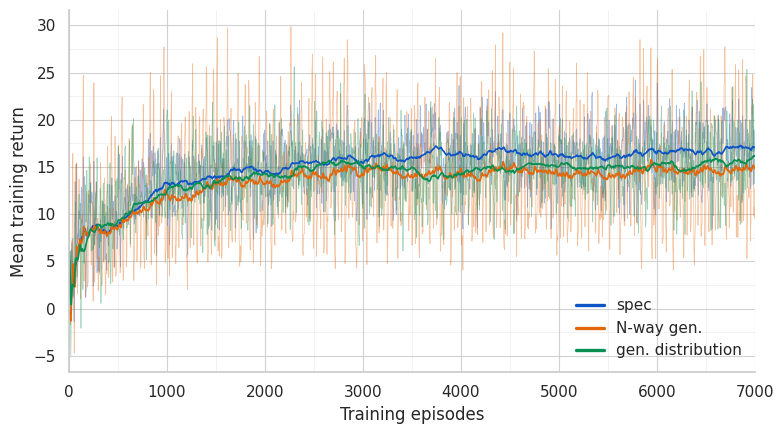

SAC — eval: saved sac_eval_return_20260923_211442_out_4.pdf


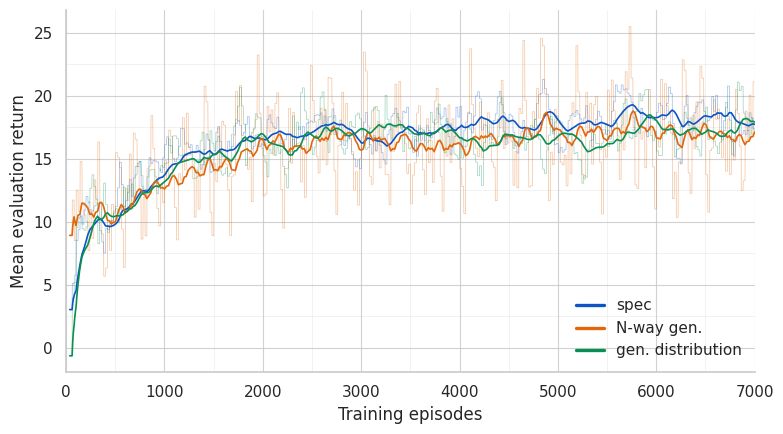

DreamerV3 — train: saved dreamerv3_train_return_20260923_211442_out_5.pdf


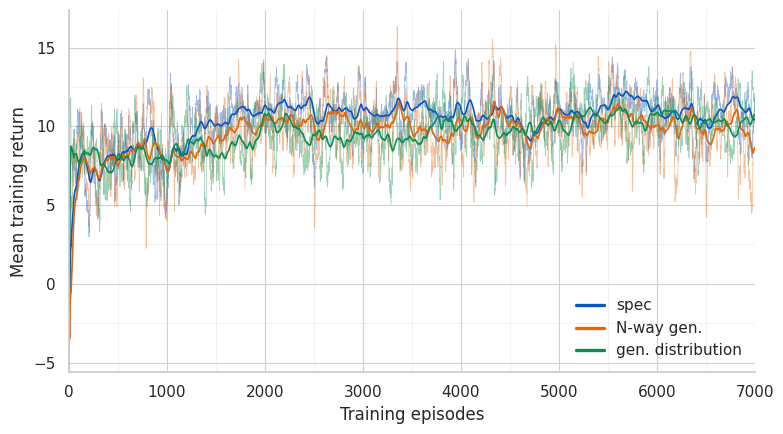

DreamerV3 — eval: saved dreamerv3_eval_return_20260923_211442_out_6.pdf


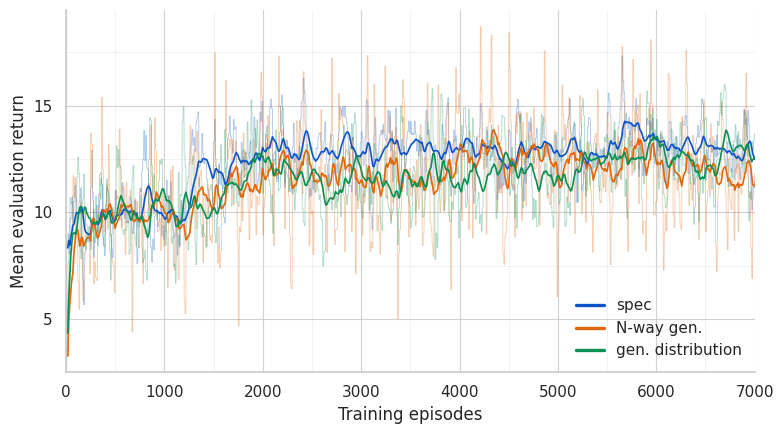

In [5]:
sns.set_theme(style="whitegrid", context="notebook")


# (divisor applied to env_steps, axis label, major-tick spacing, upper limit) for the
# configured X_AXIS. Everything is derived from the run's env-step counter, never from the
# TBX step, so logs indexed by iteration and by env step plot on the same axis.
def _x_axis_spec() -> tuple[float, str, float, float]:
    if X_AXIS == "env_steps":
        return 1e6, "Environment steps (millions)", X_TICK_ENV_STEPS / 1e6, X_MAX / 1e6
    if X_AXIS == "episodes":
        return float(EPISODE_LENGTH), "Training episodes", float(X_TICK_EPISODES), X_MAX / EPISODE_LENGTH
    raise ValueError(f"X_AXIS must be 'env_steps' or 'episodes'; got {X_AXIS!r}")


# Major ticks at the configured spacing on both axes, plus minor gridlines subdividing each
# major interval. AutoMinorLocator(n) splits an interval into n parts, so n = 1 leaves the
# minor grid empty — matplotlib rejects AutoMinorLocator(1), hence the guard.
def _apply_grid(ax) -> None:
    if X_MINOR_DIVISIONS > 1:
        ax.xaxis.set_minor_locator(AutoMinorLocator(X_MINOR_DIVISIONS))
    if Y_MINOR_DIVISIONS > 1:
        ax.yaxis.set_minor_locator(AutoMinorLocator(Y_MINOR_DIVISIONS))
    ax.grid(which="major", linewidth=0.8, alpha=0.9)
    ax.grid(which="minor", linewidth=0.4, alpha=0.45)


def plot_convergence(algo: str, column: str, y_label: str, kind: str) -> None:
    """One figure: every variant of `algo`, drawn from `column` of its extracted curve."""
    divisor, x_label, x_tick, x_max = _x_axis_spec()
    fig, ax = plt.subplots(figsize=FIGSIZE if FIGSIZE is not None else (9.0, 5.5))
    for source in (entry for entry in SOURCES if entry["algo"] == algo):
        frame = curves[(algo, source["variant"])][["env_steps", column]].dropna()
        x_values = frame["env_steps"] / divisor
        color = VARIANT_COLORS[source["variant"]]
        if SHOW_RAW:
            ax.plot(x_values, frame[column], color=color, alpha=0.40, linewidth=0.5, zorder=1)
        y_values = _tb_smooth(frame[column].to_numpy(), SMOOTHING)
        ax.plot(x_values, y_values, color=color, linewidth=1.2, label=source["variant"], zorder=2)

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_xlim(0.0, x_max)
    ax.xaxis.set_major_locator(MultipleLocator(x_tick))
    ax.yaxis.set_major_locator(MultipleLocator(Y_TICK_UNITS))
    _apply_grid(ax)
    legend = ax.legend(title="", frameon=False, loc="lower right", handlelength=1.8)
    for handle in legend.get_lines():  # bold legend swatches even though the plotted lines are thin
        handle.set_linewidth(2.4)
    sns.despine(ax=ax)
    fig.tight_layout()

    pdf_path = next_out_path(f"{algo.lower()}_{kind}_return", "pdf")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"{algo} — {kind}: saved {pdf_path.name}")
    plt.show()


for algo_name in ALGO_ORDER:
    for curve_column, axis_label, figure_kind in FIGURE_KINDS:
        plot_convergence(algo_name, curve_column, axis_label, figure_kind)